# Phase 2 — Algorithm Benchmark

Benchmarks the final algorithm comparison set against baselines.
Results are saved to `results/tables/` and consumed by `report.ipynb`.

For algorithm derivations see `algorithm_design.ipynb`.

---
## How to Use This Notebook

**All you need to change is the `RUN_MODE` variable in the Configuration cell (Section 2).**
Everything else — which cache file is loaded, analysis depth, section titles — adapts automatically.

| Mode | Cache file | Reps | When to use |
|---|---|---|---|
| `"quick"` | `benchmark_1rep.csv` | 1 | Development, checkpoint, previewing results |
| `"full"` | `benchmark_5rep.csv` | 5 | Final submission |
| `"custom"` | any file in `results/tables/` | — | Inspecting a specific backup or partial run |

**For the teachers:** to reproduce the submitted results, set `RUN_MODE = "full"` and run all cells.
`benchmark_5rep.csv` is included in the submission — the benchmark loop will be skipped and results
will load directly.

---

### Visualising results before the full run

You do not need to wait for the 5-repetition run to get meaningful results.

Setting `RUN_MODE = "quick"` loads (or produces) the 1-repetition results and runs the **same
analysis sections** as full mode — summary table, boxplots, scatter vs KNNOptK, IR-quartile
breakdown, statistical tests, and bootstrap CI. The analysis code is identical in both modes;
only the framing text adapts.

The key tool in quick mode is **Section 7 — Bootstrap Confidence Intervals**. With 1 repetition
(10 fold-results per algorithm per dataset), there is sampling noise in the per-dataset means.
The bootstrap CI quantifies that noise: it shows a 95% confidence interval around each
algorithm's mean G-mean, computed by resampling the 40 dataset-level means with replacement 2000
times. These intervals are a *prediction* of where the true mean will land once the 5-repetition
run is complete — if two algorithms have non-overlapping intervals in quick mode, they are very
likely to remain separated in the full run.

In practice the 1-repetition results in this notebook correspond to the analysis already present
in `algorithm_design.ipynb`, so the bootstrap CI you see here is the same prediction that guided our
decision to proceed to the 5-repetition run. If you load `benchmark_raw.csv` as the custom file
you can reproduce that exact analysis:

```
RUN_MODE    = "custom"
CUSTOM_FILE = "benchmark_raw.csv"
```

---
## 1. Imports

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import StratifiedKFold

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms.baseline import KNNClassifierFast, KNNOptK, KNNWeighted
from src.algorithms.fair_rank.core import KNNFairRank, KNNFairRankCV
from src.algorithms.fair_rank.ensemble import KNNFairRankEnsemble, KNNFairRankOptVotes, KNNFairRankJointCV
from src.algorithms.fair_rank.resampling import KNNFairRankJackknife
from src.algorithms.fair_rank.topology import KNNFairRankTopoJointBootstrap
from src.evaluation.metrics import compute_all_metrics
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks

cfg = load_config()
SEED = cfg["random_seed"]

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

---
## 2. Configuration

**Change only this cell.**

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# MODE TOGGLE
# ─────────────────────────────────────────────────────────────────────────────
RUN_MODE    = "full"            # "quick" | "full" | "custom"
FORCE_RERUN = False              # True = delete cached CSVs and run fresh
CUSTOM_FILE       = "benchmark_raw.csv"  # main CSV for custom mode
CUSTOM_DEGEN_FILE = None                  # degenerate CSV for custom mode (or None)
# ─────────────────────────────────────────────────────────────────────────────

_N_REPS  = {"quick": 1, "full": 5}
_CACHES  = {
    "quick":  TAB_DIR / "benchmark_1rep.csv",
    "full":   TAB_DIR / "benchmark_5rep.csv",
    "custom": TAB_DIR / CUSTOM_FILE,
}

N_REPS = _N_REPS.get(RUN_MODE, None)
CACHE  = _CACHES[RUN_MODE]

# Degenerate-dataset companion run (5-fold × 2× reps = same total evaluations)
_DEGEN_FOLDS = 5
_DEGEN_REPS  = {k: v * (cfg["evaluation"]["cv_folds"] // _DEGEN_FOLDS)
               for k, v in _N_REPS.items()}
DEGEN_REPS   = _DEGEN_REPS.get(RUN_MODE, None)
DEGEN_CACHE  = TAB_DIR / CACHE.name.replace(".csv", "_degenerate.csv") if RUN_MODE != "custom" else None

_degen_info = (
    f"`{DEGEN_CACHE.name}` (exists: {DEGEN_CACHE.exists()})" if DEGEN_CACHE
    else f"`{CUSTOM_DEGEN_FILE}`" if CUSTOM_DEGEN_FILE else "not set"
)
display(Markdown(
    f"**Active mode:** `{RUN_MODE}`  \n"
    f"**Main cache:** `{CACHE.name}` (exists: {CACHE.exists()})  \n"
    f"**Repetitions:** {N_REPS}  \n"
    f"**Degenerate cache:** {_degen_info}"
))

**Active mode:** `full`  
**Main cache:** `benchmark_5rep.csv` (exists: True)  
**Repetitions:** 5  
**Degenerate cache:** `benchmark_5rep_degenerate.csv` (exists: False)

---
## 3. Algorithm Selection

### 3.1 Full algorithm landscape

During development we tested algorithms across two research directions.
The table below documents the full landscape; results are from the 1-repetition run (G-mean, averaged over all datasets).

| Algorithm | G-mean | Direction | Status |
|---|---|---|---|
| `KNNFairRankCV` | 0.827 | Fair-rank correction | ✅ final set |
| `KNNFairRankJackknife` | 0.824 | Fair-rank correction | ✅ final set |
| `KNNFairRankLocalOdds` | 0.823 | Fair-rank correction | ❌ dominated by Jackknife variant |
| `KNNFairRankLocalOddsJackknife` | 0.821 | Fair-rank correction | ❌ redundant with FairRankJackknife |
| `KNNFairRank` | 0.820 | Fair-rank correction | ✅ final set (base) |
| `KNNFairRankMagnitudeCV` | 0.820 | Fair-rank correction | ❌ redundant with FairRankCV |
| `KNNFairRankMagnitude` | 0.815 | Fair-rank correction | ❌ dominated by CV/Ensemble variants |
| `KNNFairRankOptVotes` | TBD | Fair-rank correction | ✅ final set (inner CV on n_votes) |
| `KNNFairRankDensity` | 0.806 | Fair-rank correction | ❌ not significantly better than base |
| `SMOTE+KNN` | 0.807 | Data augmentation | ✅ final set (industry baseline) |
| `KNNWeighted` | 0.798 | Distance weighting | ✅ final set (baseline) |
| `KNNFairRankEnsemble` | 0.770 | Fair-rank correction | ✅ final set |
| `KNNFairRankMagnitudeEnsemble` | 0.786 | Fair-rank correction | ❌ redundant with FairRankEnsemble |
| `KNNFairRankJackknifeEnsemble` | 0.743 | Fair-rank correction | ❌ redundant with FairRankEnsemble |
| `KNNFairRankBayesian` | TBD | Fair-rank correction | ✅ final set (§21 Bayesian α-shrinkage) |
| `KNNFairRankDensityRegion` | TBD | Fair-rank correction | ✅ final set (§17 density-ratio partitioning) |
| `KNNAdaptiveTopo` | 0.681 | Local-k adaptation | ✅ final set (topology direction) |
| `KNNOptK` | 0.679 | CV k selection | ✅ final set (Phase 1 baseline) |
| `SMOTE+KNNOptK` | 0.734 | Data augmentation | ❌ too slow, marginal vs SMOTE+KNN |
| `KNNAdaptiveDualAnchor` | 0.556 | Local-k adaptation | ❌ underperforms KNNOptK |
| `KNNBaseline` | 0.539 | — | ❌ trivial baseline, not needed |
| `KNNAdaptiveEntropy` | 0.463 | Local-k adaptation | ❌ poor performance |
| `KNNAdaptiveEigen` | 0.404 | Local-k adaptation | ❌ poor performance |
| `DANN` | 0.380 | Distance weighting | ❌ poor performance |
| `DANNAdaptive` | 0.333 | Distance weighting | ❌ poor performance |

### 3.2 Why trim the FairRank family?

The FairRank family grew large during development. We keep the base (`KNNFairRank`), the two best-performing extensions (`KNNFairRankCV`, `KNNFairRankEnsemble`), and `KNNFairRankJackknife` to represent the stability-improvement direction. `KNNFairRankOptVotes` is included because it addresses a distinct failure mode: the fixed `n_votes=5` default sits in the dead zone between a low-votes cluster (28/45 datasets peak at n_votes ∈ {1,2}) and a high-votes cluster (12/45 datasets peak at n_votes ∈ {7,10}). Inner CV over a small candidate grid resolves this at modest overhead. `KNNFairRankBayesian` (§21) extends `KNNFairRankJointCV` with a per-query Bühlmann credibility blend of the global CV-tuned α and a local density estimate, requiring no extra hyperparameter. `KNNFairRankDensityRegion` (§17) fixes the main failure of `KNNFairRankTopoJoint`: instead of clustering the joint point cloud (dominated by majority), it estimates the per-class density ratio ρ̂ at each minority training point and gap-detects a partition in ρ̂-space, with a reliability guard ensuring every region contains at least k_ref minority points. The remaining variants are either dominated by a sibling on all metrics, statistically indistinguishable from one of the survivors (Holm-corrected Wilcoxon), or redundant in what they demonstrate.

### 3.3 Why keep `KNNAdaptiveTopo`?

`KNNAdaptiveTopo` is the best representative of the local-k adaptation direction — the first research hypothesis we pursued before arriving at the fair-rank insight. Including it tells the full story: topology-based local adaptation improves over `KNNOptK`, but is still substantially below the fair-rank family. This contrast directly motivates the structural argument that the problem is not k-selection but the rank comparison itself.


In [3]:
datasets = load_all_datasets()
print(f'Loaded {len(datasets)} datasets.')

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets.


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [4]:
import os
from imblearn.over_sampling import SMOTE
from src.evaluation.benchmarking import run_benchmark

N_JOBS     = 1
_cpu       = os.cpu_count() or 4
ALG_JOBS   = max(1, _cpu // max(1, N_JOBS))
KOPTK_JOBS = max(1, _cpu // max(1, N_JOBS))
print(f"CPUs: {_cpu}  |  N_JOBS={N_JOBS}  |  ALG_JOBS={ALG_JOBS}  |  KOPTK_JOBS={KOPTK_JOBS}")

class KNNOptKBench(KNNOptK):
    def __init__(self): super().__init__(n_jobs=KOPTK_JOBS)

class KNNFairRankBench(KNNFairRank):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankCVBench(KNNFairRankCV):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankEnsembleBench(KNNFairRankEnsemble):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankJackknifeBench(KNNFairRankJackknife):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankOptVotesBench(KNNFairRankOptVotes):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankJointCVBench(KNNFairRankJointCV):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankTopoJointBootstrapBench(KNNFairRankTopoJointBootstrap):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNWeightedBench(KNNWeighted):
    def __init__(self): super().__init__(k=5, n_jobs=ALG_JOBS)

class SMOTEKNNWrapper:
    """SMOTE resampling + fast fixed-k KNN (k=5)."""
    def __init__(self): self._clf = None

    def fit(self, X, y):
        n_minority = int(y.sum())
        k_sm = max(1, min(5, n_minority - 1))
        try:
            X_res, y_res = SMOTE(k_neighbors=k_sm, random_state=SEED).fit_resample(X, y)
        except Exception:
            X_res, y_res = X, y
        self._clf = KNNClassifierFast(k=5)
        self._clf.fit(X_res, y_res)
        self.classes_ = self._clf.classes_
        return self

    def predict(self, X): return self._clf.predict(X)
    def predict_proba(self, X): return self._clf.predict_proba(X)

# ── Final comparison set ─────────────────────────────────────────────────────
# Baselines:  KNNOptK, SMOTE+KNN, KNNWeighted
# FairRank:   KNNFairRank (base), KNNFairRankCV, KNNFairRankEnsemble,
#             KNNFairRankOptVotes, KNNFairRankJointCV, KNNFairRankJackknife
# Topology:   KNNFairRankTopoJointBootstrap
# See algorithm_design.ipynb for motivation and theoretical derivations.
ALGORITHMS = {
    "KNNOptK":                       KNNOptKBench,
    "SMOTE+KNN":                     SMOTEKNNWrapper,
    "KNNWeighted":                   KNNWeightedBench,
    "KNNFairRank":                   KNNFairRankBench,
    "KNNFairRankCV":                 KNNFairRankCVBench,
    "KNNFairRankEnsemble":           KNNFairRankEnsembleBench,
    "KNNFairRankOptVotes":           KNNFairRankOptVotesBench,
    "KNNFairRankJointCV":            KNNFairRankJointCVBench,
    "KNNFairRankJackknife":          KNNFairRankJackknifeBench,
    "KNNFairRankTopoJointBootstrap": KNNFairRankTopoJointBootstrapBench,
}

print("\nFinal comparison set:")
for name in ALGORITHMS:
    print(f"  {name}")


CPUs: 16  |  N_JOBS=1  |  ALG_JOBS=16  |  KOPTK_JOBS=16

Final comparison set:
  KNNOptK
  SMOTE+KNN
  KNNWeighted
  KNNFairRank
  KNNFairRankCV
  KNNFairRankEnsemble
  KNNFairRankOptVotes
  KNNFairRankJointCV
  KNNFairRankJackknife
  KNNFairRankTopoJointBootstrap


---
## 4. Benchmark Run

10-fold stratified CV, repeated `N_REPS` times. If the cache for the current mode already
exists the run cell prints a confirmation and skips all computation.

In [5]:
# ── Trim cached CSV to the final algorithm set ────────────────────────────────
# Safe to re-run: missing names/datasets are skipped, backups are created first.
from src.evaluation.benchmarking import drop_algorithms, drop_datasets

drop_algorithms(CACHE, [
    # Earlier exploratory variants
    "KNNFairRankDensity",
    "KNNFairRankMagnitude",
    "KNNFairRankMagnitudeCV",
    "KNNFairRankMagnitudeEnsemble",
    "KNNFairRankLocalOdds",
    "KNNFairRankJackknifeEnsemble",
    "KNNFairRankLocalOddsJackknife",
    "KNNFairRankLID",
    # Dropped in final algorithm selection (see algorithm_design.ipynb §6.1)
    "KNNAdaptiveTopo",
    "KNNFairRankTopoJoint",
    "KNNFairRankTopoCount",
    "KNNFairRankLocalCount",
    "KNNFairRankBayesian",
    "KNNFairRankDensityRegion",
])

# ── Re-run degenerate datasets after threshold-selection bug fix ───────────────
# All 4 datasets have < 20 minority samples so they are filtered out of the
# regular analysis by valid_datasets and only appear in the degenerate run
# (Section 7). Only DEGEN_CACHE needs fixing; CACHE rows are never used.
# On ultra-low-IR data the inner ROC probe was anti-correlated, causing argmax
# to select sklearn's inf sentinel. Fixed in benchmarking.py.
_BUG_DATASETS = [
    "dataset_865_analcatdata_neavote",
    "dataset_1013_analcatdata_challenger",
    "dataset_1045_kc1-top5",
    "dataset_1059_ar1",
]
if DEGEN_CACHE is not None:
    drop_datasets(DEGEN_CACHE, _BUG_DATASETS)

  Backup saved to benchmark_5rep_backup_20260508_100137.csv
  'KNNAdaptiveTopo' not found in CSV — skipped.
  'KNNFairRankBayesian' not found in CSV — skipped.
  'KNNFairRankDensity' not found in CSV — skipped.
  'KNNFairRankDensityRegion' not found in CSV — skipped.
  'KNNFairRankJackknifeEnsemble' not found in CSV — skipped.
  'KNNFairRankLID' not found in CSV — skipped.
  'KNNFairRankLocalCount' not found in CSV — skipped.
  'KNNFairRankLocalOdds' not found in CSV — skipped.
  'KNNFairRankLocalOddsJackknife' not found in CSV — skipped.
  'KNNFairRankMagnitude' not found in CSV — skipped.
  'KNNFairRankMagnitudeCV' not found in CSV — skipped.
  'KNNFairRankMagnitudeEnsemble' not found in CSV — skipped.
  'KNNFairRankTopoCount' not found in CSV — skipped.
  'KNNFairRankTopoJoint' not found in CSV — skipped.
  3000 rows remaining (10 algorithms).
  No existing CSV found — nothing to drop.


In [6]:
# Set to a name or list of names to drop cached rows and force re-run.
# Set to None for normal resume.
REPLACE_ALG = None

# ── Force-rerun: wipe stale caches so threshold-tuned results start fresh ────
if RUN_MODE != "custom" and FORCE_RERUN:
    for _p in filter(None, [CACHE, DEGEN_CACHE]):
        if _p.exists():
            _p.unlink()
            print(f"  Deleted stale cache: {_p.name}")

# ── Custom mode: always load, never run ──────────────────────────────────────
if RUN_MODE == "custom":
    if not CACHE.exists():
        available = "\n".join(f"  {p.name}" for p in sorted(TAB_DIR.glob("*.csv")))
        raise FileNotFoundError(
            f"Custom file not found: {CACHE.name}\n"
            f"Available files in results/tables/:\n{available}")
    bench_df = pd.read_csv(CACHE)
    display(Markdown(f"**Custom load:** `{CACHE.name}` — {len(bench_df):,} rows, "
                     f"{bench_df['repeat'].nunique()} repeat(s), "
                     f"{bench_df['dataset'].nunique()} datasets, "
                     f"{bench_df['algorithm'].nunique()} algorithms."))

# ── Quick / full: delegate entirely to run_benchmark ─────────────────────────
else:
    bench_df = run_benchmark(
        estimators=ALGORITHMS,
        datasets=datasets,
        output_path=CACHE,
        n_jobs=N_JOBS,
        n_repetitions=N_REPS,
        replace_algorithm=REPLACE_ALG,
    )
    display(Markdown(f"**{'Loaded from cache' if CACHE.exists() else 'Run complete'}:** "
                     f"`{CACHE.name}` — {len(bench_df):,} rows, "
                     f"{bench_df['repeat'].nunique()} repeat(s), "
                     f"{bench_df['dataset'].nunique()} datasets, "
                     f"{bench_df['algorithm'].nunique()} algorithms."))

  Resuming: 60 (dataset, algorithm) pairs already done (6 datasets fully complete, 43 partially/not started).
  Running 43 dataset(s) remaining (10 algorithm(s) each, 5 rep(s) × 10-fold).
  [1/43] dataset_1018_ipums_la_99-small  (10 alg(s))
  [2/43] dataset_1020_mfeat-karhunen  (10 alg(s))
  [3/43] dataset_1021_page-blocks  (10 alg(s))
  [4/43] dataset_1022_mfeat-pixel  (10 alg(s))
  [5/43] dataset_1023_soybean  (10 alg(s))


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning

  [6/43] dataset_1045_kc1-top5  (10 alg(s))
  [7/43] dataset_1049_pc4  (10 alg(s))
  [8/43] dataset_1050_pc3  (10 alg(s))
  [9/43] dataset_1056_mc1  (10 alg(s))


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning

  [10/43] dataset_1059_ar1  (10 alg(s))
  [11/43] dataset_1061_ar4  (10 alg(s))
  [12/43] dataset_1064_ar6  (10 alg(s))
  [13/43] dataset_1065_kc3  (10 alg(s))
  [14/43] dataset_311_oil_spill  (10 alg(s))
  [15/43] dataset_312_scene  (10 alg(s))
  [16/43] dataset_316_yeast_ml8  (10 alg(s))
  [17/43] dataset_38_sick  (10 alg(s))
  [18/43] dataset_450_analcatdata_lawsuit  (10 alg(s))
  [19/43] dataset_463_backache  (10 alg(s))
  [20/43] dataset_757_meta  (10 alg(s))
  [21/43] dataset_764_analcatdata_apnea3  (10 alg(s))
  [22/43] dataset_765_analcatdata_apnea2  (10 alg(s))
  [23/43] dataset_767_analcatdata_apnea1  (10 alg(s))


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning

  [24/43] dataset_865_analcatdata_neavote  (10 alg(s))
  [25/43] dataset_867_visualizing_livestock  (10 alg(s))
  [26/43] dataset_875_analcatdata_chlamydia  (10 alg(s))
  [27/43] dataset_940_water-treatment  (10 alg(s))
  [28/43] dataset_947_arsenic-male-bladder  (10 alg(s))
  [29/43] dataset_949_arsenic-female-bladder  (10 alg(s))
  [30/43] dataset_950_arsenic-female-lung  (10 alg(s))
  [31/43] dataset_951_arsenic-male-lung  (10 alg(s))
  [32/43] dataset_954_spectrometer  (10 alg(s))
  [33/43] dataset_958_segment  (10 alg(s))
  [34/43] dataset_962_mfeat-morphological  (10 alg(s))
  [35/43] dataset_966_analcatdata_halloffame  (10 alg(s))
  [36/43] dataset_968_analcatdata_birthday  (10 alg(s))
  [37/43] dataset_971_mfeat-fourier  (10 alg(s))
  [38/43] dataset_976_JapaneseVowels  (10 alg(s))
  [39/43] dataset_978_mfeat-factors  (10 alg(s))
  [40/43] dataset_980_optdigits  (10 alg(s))
  [41/43] dataset_984_analcatdata_draft  (10 alg(s))
  [42/43] dataset_987_collins  (10 alg(s))
  [43/43]

**Loaded from cache:** `benchmark_5rep.csv` — 24,500 rows, 5 repeat(s), 49 datasets, 10 algorithms.

In [7]:
# ── Recovery: run this if the benchmark cell was interrupted ─────────────────
# bench_df is only defined in memory if the benchmark cell ran to completion.
# Since run_benchmark saves incrementally, partial results are always on disk.
if "bench_df" not in globals():
    if CACHE.exists():
        bench_df = pd.read_csv(CACHE)
        display(Markdown(
            f"**Partial results loaded from interrupted run:** `{CACHE.name}` — "
            f"{len(bench_df):,} rows, "
            f"{bench_df['repeat'].nunique()} repeat(s), "
            f"{bench_df['dataset'].nunique()} datasets, "
            f"{bench_df['algorithm'].nunique()} algorithms."
        ))
    else:
        raise RuntimeError("bench_df is not defined and no cache file found — run the benchmark first.")


In [8]:
# ── Degenerate-dataset benchmark ─────────────────────────────────────────────
# Datasets with < 2 × standard_cv_folds minority samples cannot use 10-fold CV
# reliably (some test folds contain 0 minority examples). We substitute
# 5-fold × 2× repetitions to keep the total number of evaluations identical
# while guaranteeing ≥ 1 minority example per test fold.
#
# Results go to a SEPARATE cache (_degenerate suffix) — the fold layout differs
# from the main run so the two files must never be mixed. Statistical analysis
# of this subset is descriptive only (n ≈ 9, insufficient power for Wilcoxon).
if RUN_MODE in ("quick", "full"):
    _std_folds      = cfg["evaluation"]["cv_folds"]
    _min_minority   = 2 * _std_folds

    degen_datasets  = [
        ds for ds in datasets
        if int(binarise_labels(ds.y).sum()) < _min_minority
    ]

    display(Markdown(
        f"**Degenerate datasets** (< {_min_minority} minority samples): "
        f"{len(degen_datasets)} found  \n"
        f"**CV scheme:** {_DEGEN_FOLDS}-fold × {DEGEN_REPS} reps "
        f"= {_DEGEN_FOLDS * DEGEN_REPS} evaluations per pair  \n"
        f"**Cache:** `{DEGEN_CACHE.name}`"
    ))

    if degen_datasets:
        degen_bench_df = run_benchmark(
            estimators=ALGORITHMS,
            datasets=degen_datasets,
            output_path=DEGEN_CACHE,
            n_jobs=N_JOBS,
            n_repetitions=DEGEN_REPS,
            n_cv_splits=_DEGEN_FOLDS,
        )
        display(Markdown(
            f"**Degenerate run complete:** `{DEGEN_CACHE.name}` — "
            f"{len(degen_bench_df):,} rows, "
            f"{degen_bench_df['repeat'].nunique()} repeat(s), "
            f"{degen_bench_df['dataset'].nunique()} datasets, "
            f"{degen_bench_df['algorithm'].nunique()} algorithms."
        ))
    else:
        display(Markdown("No degenerate datasets found — nothing to run."))
else:  # custom
    if CUSTOM_DEGEN_FILE is not None:
        degen_bench_df = pd.read_csv(TAB_DIR / CUSTOM_DEGEN_FILE)
        _name = CUSTOM_DEGEN_FILE
        display(Markdown(
            f"**Custom degenerate load:** `{_name}` — "
            f"{len(degen_bench_df):,} rows, "
            f"{degen_bench_df['dataset'].nunique()} datasets, "
            f"{degen_bench_df['algorithm'].nunique()} algorithms."
        ))
    else:
        degen_bench_df = None
        display(Markdown(
            "Custom mode — no degenerate file specified. "
            "Set `CUSTOM_DEGEN_FILE` in the config cell to load one."
        ))


**Degenerate datasets** (< 20 minority samples): 9 found  
**CV scheme:** 5-fold × 10 reps = 50 evaluations per pair  
**Cache:** `benchmark_5rep_degenerate.csv`

  Running 9 dataset(s) remaining (10 algorithm(s) each, 10 rep(s) × 5-fold).
  [1/9] dataset_1013_analcatdata_challenger  (10 alg(s))
  [2/9] dataset_1045_kc1-top5  (10 alg(s))
  [3/9] dataset_1059_ar1  (10 alg(s))
  [4/9] dataset_1064_ar6  (10 alg(s))
  [5/9] dataset_450_analcatdata_lawsuit  (10 alg(s))
  [6/9] dataset_865_analcatdata_neavote  (10 alg(s))
  [7/9] dataset_875_analcatdata_chlamydia  (10 alg(s))
  [8/9] dataset_950_arsenic-female-lung  (10 alg(s))
  [9/9] dataset_951_arsenic-male-lung  (10 alg(s))


**Degenerate run complete:** `benchmark_5rep_degenerate.csv` — 4,500 rows, 5 repeat(s), 9 datasets, 10 algorithms.

In [9]:
# ── Recovery: ensures degen_bench_df is always defined ─────────────────────────
# Run after a kernel restart or interrupted degenerate benchmark.
# Sets degen_bench_df = None when no data is available so analysis cells
# can safely guard with `if _degen_ok`.
if 'degen_bench_df' not in globals():
    if DEGEN_CACHE is not None and DEGEN_CACHE.exists():
        degen_bench_df = pd.read_csv(DEGEN_CACHE)
        display(Markdown(
            f'**Degenerate results loaded from disk:** `{DEGEN_CACHE.name}` — '
            f'{len(degen_bench_df):,} rows, '
            f"{degen_bench_df['repeat'].nunique()} repeat(s), "
            f"{degen_bench_df['dataset'].nunique()} datasets."
        ))
    elif RUN_MODE == 'custom' and CUSTOM_DEGEN_FILE is not None:
        degen_bench_df = pd.read_csv(TAB_DIR / CUSTOM_DEGEN_FILE)
        display(Markdown(
            f'**Custom degenerate load:** `{CUSTOM_DEGEN_FILE}` — '
            f'{len(degen_bench_df):,} rows.'
        ))
    else:
        degen_bench_df = None
        display(Markdown(
            'No degenerate results available — `degen_bench_df` set to `None`. '
            'The degenerate analysis section (Section 7) will be skipped.'
        ))


---
## 5. Post-Benchmark Data Preparation

In [10]:
# ── Derive all threshold-based metrics from raw confusion matrix ──────────────
# The CSV stores only (tp, tn, fp, fn, roc_auc, pr_auc).  Every other metric
# is arithmetic on those four counts — so adding a new metric never requires
# re-running the benchmark.
_CM_COLS = {"tp", "tn", "fp", "fn"}
if not _CM_COLS.issubset(bench_df.columns):
    raise ValueError(
        "Cache file uses the old schema (no confusion matrix columns). "
        "Delete the cache and re-run the benchmark with the updated code."
    )

def _derive_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    tp = df["tp"].astype(float)
    tn = df["tn"].astype(float)
    fp = df["fp"].astype(float)
    fn = df["fn"].astype(float)

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp)

    df["recall"]            = sensitivity
    df["precision"]         = precision
    df["f1"]                = 2 * tp / (2 * tp + fp + fn)
    df["balanced_accuracy"] = (sensitivity + specificity) / 2
    df["geometric_mean"]    = np.sqrt(sensitivity * specificity)

    mcc_num = tp * tn - fp * fn
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    df["mcc"] = np.where(mcc_den == 0, 0.0, mcc_num / mcc_den)

    return df

bench_df = _derive_metrics(bench_df)
print("Derived metrics added:", ["recall", "precision", "f1", "balanced_accuracy", "geometric_mean", "mcc"])

Derived metrics added: ['recall', 'precision', 'f1', 'balanced_accuracy', 'geometric_mean', 'mcc']


In [11]:
# Filter degenerate datasets (fewer than 2*cv_folds minority samples → unreliable CV)
min_minority = 2 * cfg["evaluation"]["cv_folds"]
valid_datasets = [
    ds.name for ds in datasets
    if int(binarise_labels(ds.y).sum()) >= min_minority
]
removed = bench_df[~bench_df["dataset"].isin(valid_datasets)]["dataset"].unique()
bench_df = bench_df[bench_df["dataset"].isin(valid_datasets)].reset_index(drop=True)
print(f"Removed {len(removed)} degenerate datasets: {list(removed)}")
print(f"Remaining: {bench_df['dataset'].nunique()} datasets, {bench_df['algorithm'].nunique()} algorithms")

# Full mode: restrict to the final comparison set only
# Quick / custom: analyse all algorithms present in the file
if RUN_MODE == "full":
    FINAL_ALGS = list(ALGORITHMS.keys())
    bench_df = bench_df[bench_df["algorithm"].isin(FINAL_ALGS)].reset_index(drop=True)
    print(f"Full mode — restricted to final algorithm set: {sorted(bench_df['algorithm'].unique().tolist())}")
else:
    print(f"{'Quick' if RUN_MODE == 'quick' else 'Custom'} mode — all algorithms in file: {sorted(bench_df['algorithm'].unique().tolist())}")

# ── Detect actual rep count from data and derive mode metadata ────────────────
N_ACTUAL_REPS = bench_df["repeat"].nunique()

if RUN_MODE == "custom":
    # Treat as final if the file has 5+ reps; preliminary otherwise
    IS_FINAL   = N_ACTUAL_REPS >= 5
    _desc      = f"final ({N_ACTUAL_REPS} reps)" if IS_FINAL else f"preliminary ({N_ACTUAL_REPS} rep(s))"
    MODE_LABEL = f"Custom: {CACHE.name} — {_desc}"
    FILE_SUFFIX = CACHE.stem   # e.g. "benchmark_raw" → outputs named *_benchmark_raw.*
else:
    IS_FINAL    = (RUN_MODE == "full")
    MODE_LABEL  = (f"Final results — {N_ACTUAL_REPS} reps"
                   if IS_FINAL else
                   f"Preliminary — predicting full run ({N_ACTUAL_REPS} rep)")
    FILE_SUFFIX = f"{N_ACTUAL_REPS}rep"   # "1rep" or "5rep" — self-documenting

display(Markdown(
    f"**Mode:** `{RUN_MODE}` | **Reps in data:** {N_ACTUAL_REPS} | "
    f"**Treated as:** {'final' if IS_FINAL else 'preliminary'} | "
    f"**Output suffix:** `_{FILE_SUFFIX}`  \n"
    f"**Label:** {MODE_LABEL}"
))

Removed 9 degenerate datasets: ['dataset_1013_analcatdata_challenger', 'dataset_1045_kc1-top5', 'dataset_1059_ar1', 'dataset_1064_ar6', 'dataset_450_analcatdata_lawsuit', 'dataset_865_analcatdata_neavote', 'dataset_875_analcatdata_chlamydia', 'dataset_950_arsenic-female-lung', 'dataset_951_arsenic-male-lung']
Remaining: 40 datasets, 10 algorithms
Full mode — restricted to final algorithm set: ['KNNFairRank', 'KNNFairRankCV', 'KNNFairRankEnsemble', 'KNNFairRankJackknife', 'KNNFairRankJointCV', 'KNNFairRankOptVotes', 'KNNFairRankTopoJointBootstrap', 'KNNOptK', 'KNNWeighted', 'SMOTE+KNN']


**Mode:** `full` | **Reps in data:** 5 | **Treated as:** final | **Output suffix:** `_5rep`  
**Label:** Final results — 5 reps

---
## 5.0 Metrics for Imbalanced Binary Classification — Interpretation Guide

Before reading the benchmark tables, it is important to understand *what each metric measures* and *why metric choice matters under class imbalance*. The four metrics we track below each reward different things, and the "best" algorithm can change depending on which metric you privilege.

### 5.0.1 The Failure of Accuracy

Plain accuracy is unusable here. With 99% majority / 1% minority (common in our dataset collection), a trivial classifier that always predicts majority scores 99% accuracy — yet has zero diagnostic value. Every metric below is designed to not be fooled by this.

### 5.0.2 Building Blocks: The Confusion Matrix

For binary classification with the minority class as the "positive" class:

|  | Predicted minority | Predicted majority |
|---|---|---|
| **Actual minority** | TP (true positive) | FN (false negative) |
| **Actual majority** | FP (false positive) | TN (true negative) |

From these we derive the two class-specific recall rates:

$$\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{TNR} = \frac{TN}{TN + FP}$$

All threshold-based metrics in this notebook are derived from (TP, TN, FP, FN) — the raw counts stored in the benchmark CSV — so adding a new metric never requires re-running the benchmark.

### 5.0.3 Matthews Correlation Coefficient (MCC) ⭐ *primary*

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

MCC is the correlation coefficient between the true and predicted binary labels. It ranges from −1 (perfect inversion) through 0 (random) to +1 (perfect prediction). Unlike F1, it is **symmetric** — it penalises both false positives and false negatives, and both class-level errors matter equally. Unlike G-mean, MCC accounts for all four confusion matrix quadrants, including TN, making it more informative when the majority class also matters. It is recommended as the single most reliable binary classification metric by Chicco & Jurman (2020) precisely because it does not inflate with class imbalance and cannot be optimised by always predicting the majority class.

### 5.0.4 F1 Score

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{TPR}}{\text{Precision} + \text{TPR}}$$

Harmonic mean of minority-class precision and recall. Does not use TN — ignores majority-class errors entirely. Standard in the broader ML literature but **asymmetric** and sensitive to minority-class precision, which systematically penalises algorithms that trade precision for balanced recall. Reported for comparability with the broader ML literature.

### 5.0.5 G-mean

$$\text{G-mean} = \sqrt{\text{TPR} \cdot \text{TNR}}$$

Geometric mean of both class recalls. If either recall is zero, G-mean = 0. Introduced specifically for imbalanced classification (Kubat & Matwin 1997), symmetric, and punishes asymmetry. Reported alongside MCC as it is the standard in the class-imbalance literature and allows direct comparison with prior work.

### 5.0.6 ROC AUC

Probability that a randomly chosen minority sample is ranked higher than a randomly chosen majority sample. Threshold-independent — evaluates ranking quality, not hard-label performance. Useful to diagnose whether a classifier with low MCC/G-mean has good underlying discrimination that a better threshold could unlock. Requires predicted probability scores (not derivable from the confusion matrix alone), so it is stored directly in the benchmark CSV.

### 5.0.7 Which Metric Is Primary?

**MCC** is the primary metric for this project. It uses all four confusion matrix cells, is symmetric across classes, ranges in [−1, +1] independently of class prevalence, and cannot be gamed by predicting majority — unlike accuracy, F1, or even G-mean. Results are ordered by MCC throughout; G-mean is reported as the standard imbalance-literature metric for comparability with prior work.

---
## 5.1 Overall Mean Metrics per Algorithm

In [12]:
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks, critical_difference

METRICS = ["mcc", "f1", "geometric_mean", "roc_auc"]

summary_table = (
    bench_df
    .groupby("algorithm")[METRICS]
    .mean()
    .round(4)
    .sort_values("mcc", ascending=False)
)
summary_table.to_csv(TAB_DIR / f"benchmark_summary_{FILE_SUFFIX}.csv")

# Delta vs KNNOptK
optk_means = summary_table.loc["KNNOptK"]
delta_table = (summary_table - optk_means).round(4)
delta_table.columns = [f"Δ_{c}" for c in delta_table.columns]

display_table = pd.concat([summary_table, delta_table], axis=1)
print(f"Mean metrics — {MODE_LABEL}")
print("(Δ columns = difference vs KNNOptK)")
print(display_table.to_string())

print("\nPer-metric leaders:")
for m in METRICS:
    leader = summary_table[m].idxmax()
    print(f"  {m:<22}  →  {leader:<28}  ({summary_table.loc[leader, m]:.4f})")

ALG_ORDER = summary_table.index.tolist()
display_table

Mean metrics — Final results — 5 reps
(Δ columns = difference vs KNNOptK)
                                  mcc      f1  geometric_mean  roc_auc   Δ_mcc    Δ_f1  Δ_geometric_mean  Δ_roc_auc
algorithm                                                                                                          
KNNFairRankEnsemble            0.5757  0.6062          0.8133   0.8842  0.0214  0.0165            0.1246     0.0813
KNNFairRankJointCV             0.5716  0.6039          0.8148   0.8625  0.0173  0.0142            0.1261     0.0596
KNNWeighted                    0.5603  0.5961          0.7432   0.8412  0.0060  0.0064            0.0545     0.0383
SMOTE+KNN                      0.5585  0.5981          0.8049   0.8502  0.0042  0.0084            0.1162     0.0473
KNNFairRankCV                  0.5555  0.5882          0.8116   0.8671  0.0012 -0.0015            0.1229     0.0642
KNNOptK                        0.5543  0.5897          0.6887   0.8029  0.0000  0.0000            0.0000     0.000

,mcc,f1,geometric_mean,roc_auc,Δ_mcc,Δ_f1,Δ_geometric_mean,Δ_roc_auc
algorithm,,,,,,,,
KNNFairRankEnsemble,0.5757,0.6062,0.8133,0.8842,0.0214,0.0165,0.1246,0.0813
KNNFairRankJointCV,0.5716,0.6039,0.8148,0.8625,0.0173,0.0142,0.1261,0.0596
KNNWeighted,0.5603,0.5961,0.7432,0.8412,0.0060,0.0064,0.0545,0.0383
SMOTE+KNN,0.5585,0.5981,0.8049,0.8502,0.0042,0.0084,0.1162,0.0473
KNNFairRankCV,0.5555,0.5882,0.8116,0.8671,0.0012,-0.0015,0.1229,0.0642
KNNOptK,0.5543,0.5897,0.6887,0.8029,0.0000,0.0000,0.0000,0.0000
KNNFairRankJackknife,0.5540,0.5856,0.8185,0.8731,-0.0003,-0.0041,0.1298,0.0702
KNNFairRankTopoJointBootstrap,0.5513,0.5848,0.8152,0.8622,-0.0030,-0.0049,0.1265,0.0593
KNNFairRank,0.5386,0.5713,0.8197,0.8629,-0.0157,-0.0184,0.1310,0.0600


### 5.2 Boxplots: Per-Fold Distribution

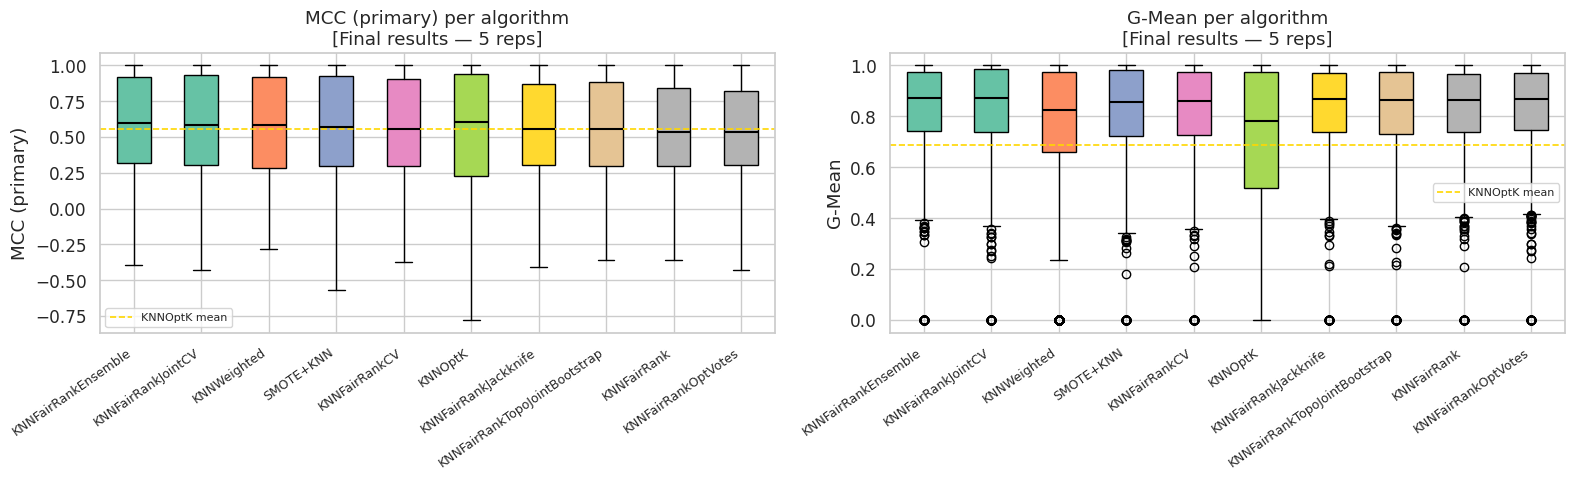

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ["mcc", "geometric_mean"], ["MCC (primary)", "G-Mean"]):
    data_plot = [bench_df[bench_df["algorithm"] == alg][metric].dropna().values for alg in ALG_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(ALG_ORDER)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(ALG_ORDER) + 1))
    ax.set_xticklabels(ALG_ORDER, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f"{label} per algorithm\n[{MODE_LABEL}]")
    ax.axhline(summary_table.loc["KNNOptK", metric], color="gold",
               linestyle="--", linewidth=1.2, label="KNNOptK mean")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_boxplots_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Per-Dataset Scatter vs KNNOptK

Each point is one dataset. Above the diagonal = improvement over KNNOptK.

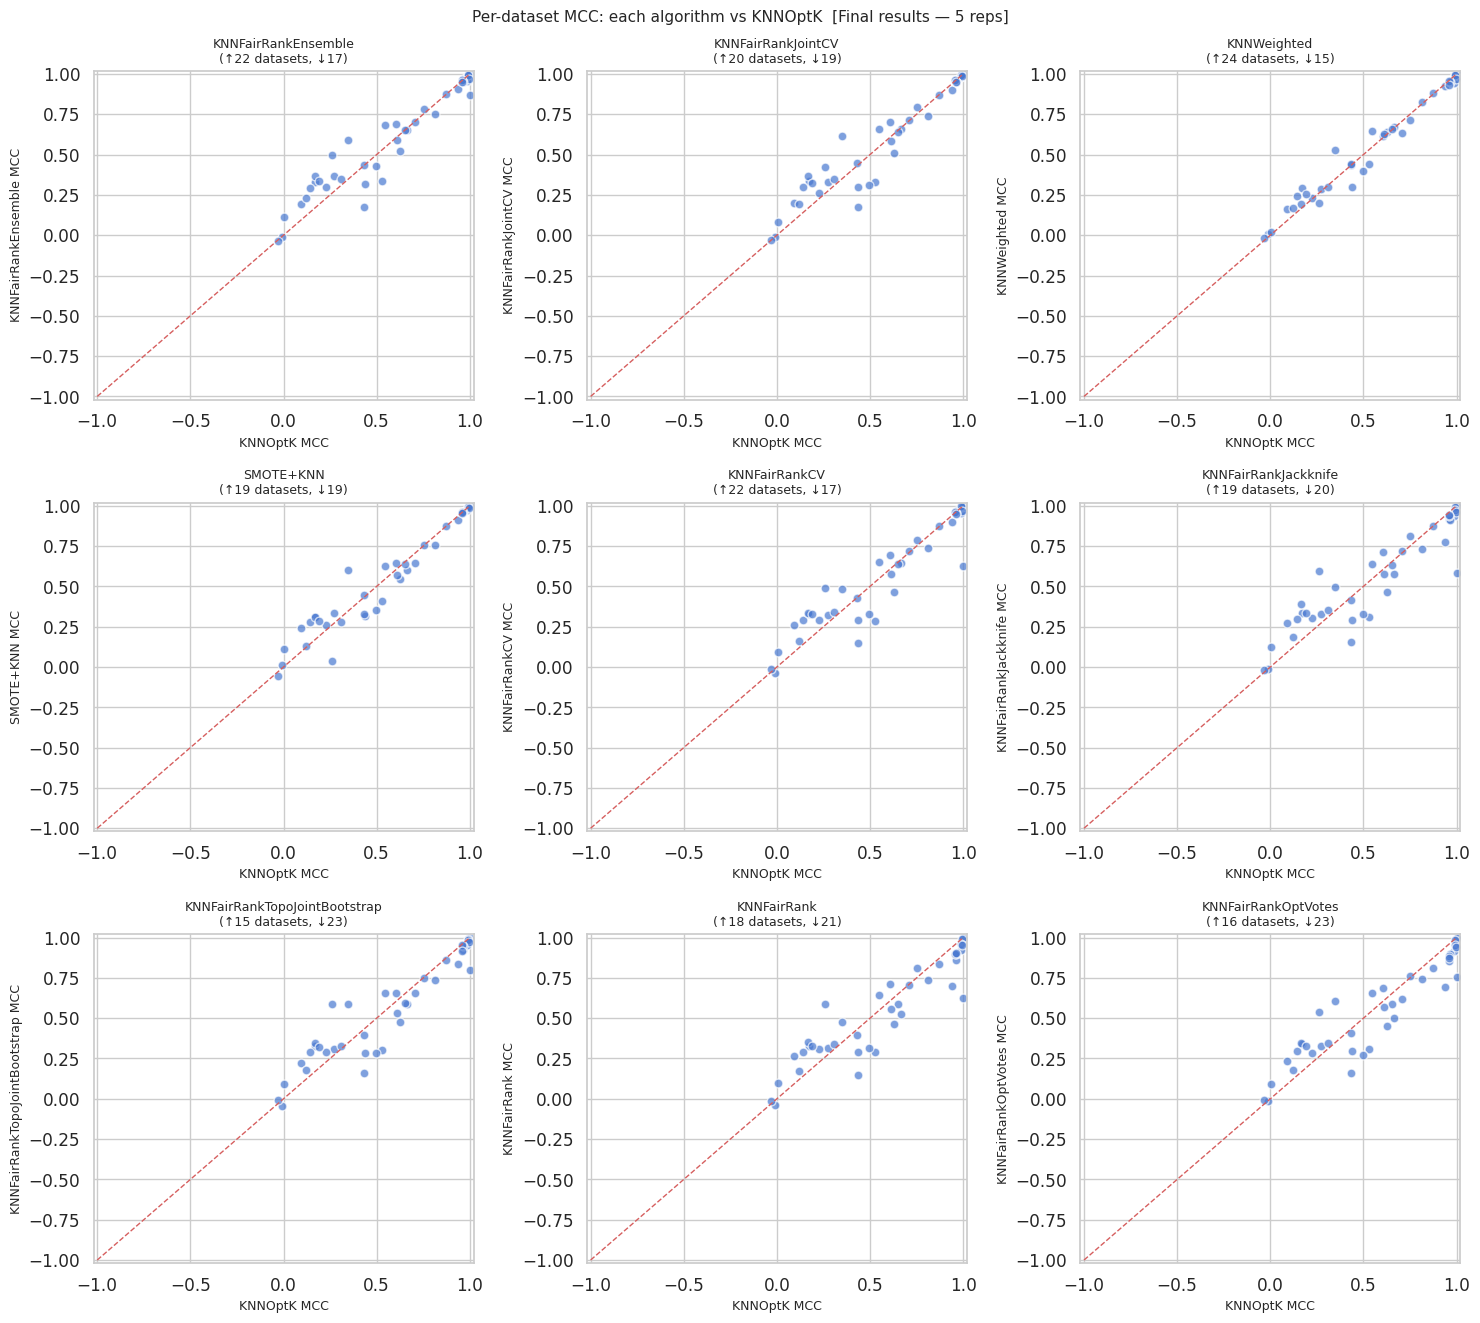

In [14]:
per_ds_alg = (
    bench_df
    .groupby(["dataset", "algorithm"])["mcc"]
    .mean()
    .unstack("algorithm")
)

competitors = [a for a in ALG_ORDER if a != "KNNOptK"]
n_cols = 3
n_rows = int(np.ceil(len(competitors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ax, alg in zip(axes, competitors):
    x = per_ds_alg["KNNOptK"]
    y_alg = per_ds_alg[alg]
    wins = (y_alg > x).sum()
    losses = (y_alg < x).sum()
    ax.scatter(x, y_alg, alpha=0.7, edgecolors="white", s=40)
    ax.plot([-1, 1], [-1, 1], "r--", linewidth=1)
    ax.set_xlabel("KNNOptK MCC", fontsize=9)
    ax.set_ylabel(f"{alg} MCC", fontsize=9)
    ax.set_title(f"{alg}\n(↑{wins} datasets, ↓{losses})", fontsize=9)
    ax.set_xlim(-1.02, 1.02); ax.set_ylim(-1.02, 1.02)

for ax in axes[len(competitors):]:
    ax.set_visible(False)

fig.suptitle(f"Per-dataset MCC: each algorithm vs KNNOptK  [{MODE_LABEL}]", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_scatter_vs_optk_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Performance by Imbalance Severity (IR Quartiles)

/tmp/ipykernel_5275/1086948853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_summary_mcc   = (bench_df.groupby(["IR_quartile", "algorithm"])["mcc"]
/tmp/ipykernel_5275/1086948853.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_summary_gmean = (bench_df.groupby(["IR_quartile", "algorithm"])["geometric_mean"]


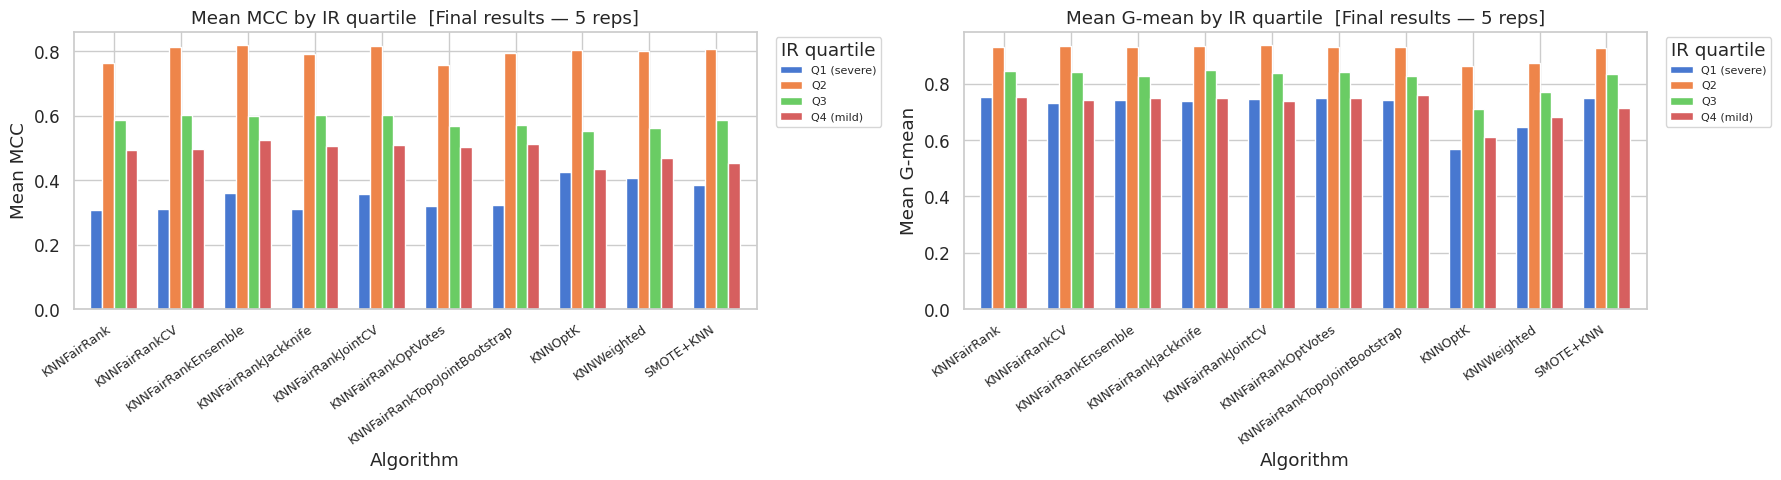

MCC by IR quartile (primary metric):
algorithm    KNNFairRank  KNNFairRankCV  KNNFairRankEnsemble  KNNFairRankJackknife  KNNFairRankJointCV  KNNFairRankOptVotes  KNNFairRankTopoJointBootstrap  KNNOptK  KNNWeighted  SMOTE+KNN
IR_quartile                                                                                                                                                                                
Q1 (severe)       0.3071         0.3095               0.3605                0.3116              0.3562               0.3195                         0.3219   0.4247       0.4076     0.3858
Q2                0.7638         0.8130               0.8195                0.7928              0.8176               0.7579                         0.7966   0.8049       0.8025     0.8082
Q3                0.5886         0.6013               0.5989                0.6041              0.6015               0.5697                         0.5730   0.5540       0.5633     0.5869
Q4 (mild)         0.495

In [15]:
bench_df["IR_quartile"] = pd.qcut(bench_df["imbalance_ratio"], q=4,
                                   labels=["Q1 (severe)", "Q2", "Q3", "Q4 (mild)"])

ir_summary_mcc   = (bench_df.groupby(["IR_quartile", "algorithm"])["mcc"]
                    .mean().unstack("algorithm").round(4))
ir_summary_gmean = (bench_df.groupby(["IR_quartile", "algorithm"])["geometric_mean"]
                    .mean().unstack("algorithm").round(4))

ir_summary_mcc.to_csv(TAB_DIR / f"benchmark_by_ir_quartile_{FILE_SUFFIX}.csv")
ir_summary_gmean.to_csv(TAB_DIR / f"benchmark_by_ir_quartile_gmean_{FILE_SUFFIX}.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, tbl, label in zip(axes, [ir_summary_mcc, ir_summary_gmean], ["MCC", "G-mean"]):
    tbl.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"Mean {label} by IR quartile  [{MODE_LABEL}]")
    ax.legend(title="IR quartile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / f"benchmark_by_ir_quartile_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

print("MCC by IR quartile (primary metric):")
print(ir_summary_mcc.to_string())

---
## 5.5 Bootstrap Confidence Intervals

In [16]:
if RUN_MODE == "full":
    display(Markdown(
        "**Full run — confirming stability.** "
        "These are the final results. Bootstrap CI shows the uncertainty from the finite dataset pool: "
        "if two algorithms have non-overlapping intervals they are robustly separated across the benchmark."))
else:
    display(Markdown(
        "**Quick / custom run — predicting the full-run result.** "
        "With 1 repetition (10 fold-results per algorithm per dataset) there is sampling noise in the "
        "per-dataset means. Bootstrap CI resamples the dataset-level means to predict where the true mean "
        "will land in the 5-repetition run. Non-overlapping intervals mean the ranking is very likely to "
        "survive the full run."))

**Full run — confirming stability.** These are the final results. Bootstrap CI shows the uncertainty from the finite dataset pool: if two algorithms have non-overlapping intervals they are robustly separated across the benchmark.

In [17]:
B_BOOT = 2000
ALPHA_CI = 0.05
rng_ci = np.random.default_rng(SEED)

per_ds_metric = bench_df.groupby(["dataset", "algorithm"])[METRICS].mean()

ci_rows = []
for metric in METRICS:
    pivot = per_ds_metric[metric].unstack("algorithm")
    for alg in pivot.columns:
        vals = pivot[alg].dropna().values
        n = len(vals)
        obs_mean = vals.mean()
        boot_means = np.array([
            rng_ci.choice(vals, size=n, replace=True).mean()
            for _ in range(B_BOOT)
        ])
        lo = np.percentile(boot_means, 100 * ALPHA_CI / 2)
        hi = np.percentile(boot_means, 100 * (1 - ALPHA_CI / 2))
        ci_rows.append({
            "algorithm": alg, "metric": metric,
            "mean": round(obs_mean, 4),
            "ci_lower": round(lo, 4),
            "ci_upper": round(hi, 4),
            "ci_width": round(hi - lo, 4),
            "n_datasets": n,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(TAB_DIR / f"bootstrap_ci_{FILE_SUFFIX}.csv", index=False)

for metric, label in [("mcc", "MCC (primary)"), ("geometric_mean", "G-mean")]:
    m_ci = (ci_df[ci_df["metric"] == metric]
            .set_index("algorithm")
            .sort_values("mean", ascending=False))
    n_ds = int(m_ci["n_datasets"].iloc[0])
    print(f"\nBootstrap 95% CI — {label}  (B={B_BOOT}, {n_ds} datasets) [{MODE_LABEL}]")
    print("{:<28} {:>9} {:>22}  {:>8}".format("Algorithm", "Mean", "95% CI", "Width"))
    print("-" * 72)
    for alg, row in m_ci.iterrows():
        ci_str = "[{:.4f}, {:.4f}]".format(row["ci_lower"], row["ci_upper"])
        print("{:<28} {:>9.4f} {:>22}  {:>8.4f}".format(alg, row["mean"], ci_str, row["ci_width"]))


Bootstrap 95% CI — MCC (primary)  (B=2000, 40 datasets) [Final results — 5 reps]
Algorithm                         Mean                 95% CI     Width
------------------------------------------------------------------------
KNNFairRankEnsemble             0.5757       [0.4820, 0.6663]    0.1842
KNNFairRankJointCV              0.5716       [0.4730, 0.6728]    0.1998
KNNWeighted                     0.5603       [0.4604, 0.6641]    0.2037
SMOTE+KNN                       0.5585       [0.4609, 0.6598]    0.1990
KNNFairRankCV                   0.5555       [0.4611, 0.6462]    0.1851
KNNOptK                         0.5543       [0.4504, 0.6584]    0.2080
KNNFairRankJackknife            0.5540       [0.4655, 0.6458]    0.1802
KNNFairRankTopoJointBootstrap    0.5513       [0.4591, 0.6463]    0.1872
KNNFairRank                     0.5386       [0.4459, 0.6246]    0.1787
KNNFairRankOptVotes             0.5374       [0.4516, 0.6286]    0.1770

Bootstrap 95% CI — G-mean  (B=2000, 40 datasets) [F

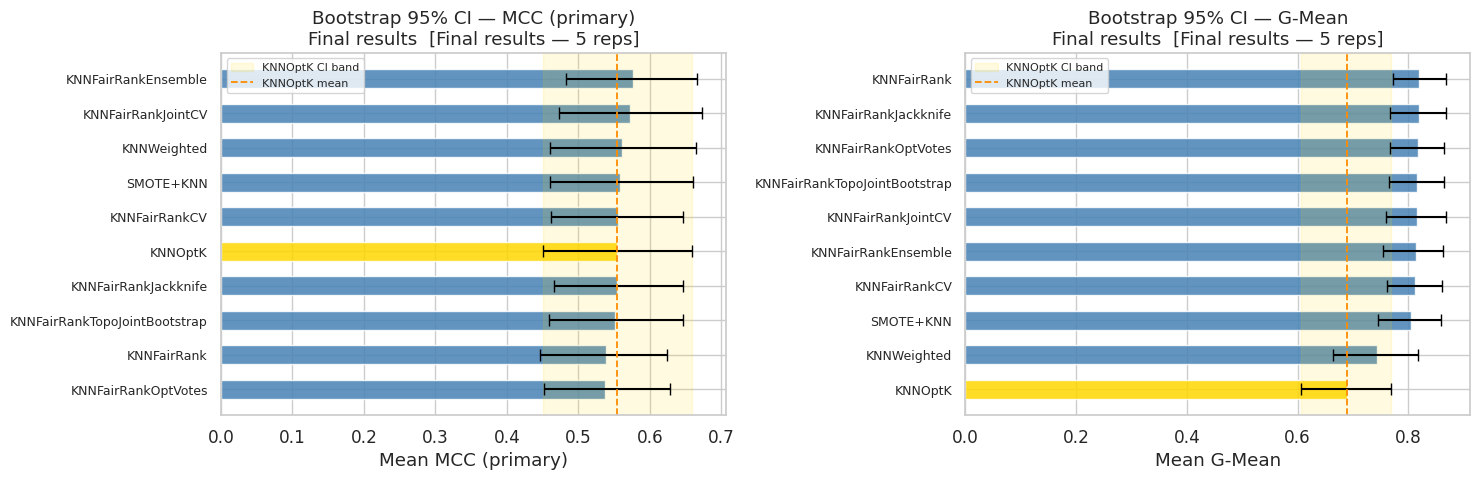

Gold band = KNNOptK 95% CI. Algorithms whose CI does not overlap with the band
are robustly separated from the Phase 1 baseline.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(axes, ["mcc", "geometric_mean"], ["MCC (primary)", "G-Mean"]):
    m_ci = (ci_df[ci_df["metric"] == metric]
            .set_index("algorithm")
            .sort_values("mean", ascending=False))
    algs = m_ci.index.tolist()
    y = np.arange(len(algs))
    colors = ["gold" if a == "KNNOptK" else "steelblue" for a in algs]

    ax.barh(y, m_ci["mean"],
            xerr=[m_ci["mean"] - m_ci["ci_lower"], m_ci["ci_upper"] - m_ci["mean"]],
            height=0.55, capsize=4, color=colors, ecolor="black", alpha=0.85)

    if "KNNOptK" in m_ci.index:
        optk_lo = m_ci.loc["KNNOptK", "ci_lower"]
        optk_hi = m_ci.loc["KNNOptK", "ci_upper"]
        ax.axvspan(optk_lo, optk_hi, alpha=0.12, color="gold", label="KNNOptK CI band")
        ax.axvline(m_ci.loc["KNNOptK", "mean"], color="darkorange",
                   linestyle="--", linewidth=1.3, label="KNNOptK mean")

    ax.set_yticks(y); ax.set_yticklabels(algs, fontsize=9)
    ci_title = "Final results" if IS_FINAL else "Predicting full-run result"
    ax.set(xlabel=f"Mean {label}",
           title=f"Bootstrap 95% CI — {label}\n{ci_title}  [{MODE_LABEL}]")
    ax.invert_yaxis(); ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"bootstrap_ci_forest_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gold band = KNNOptK 95% CI. Algorithms whose CI does not overlap with the band")
print("are robustly separated from the Phase 1 baseline.")

---
## 6. Statistical Analysis

Following Demšar (2006):

1. **Friedman test** — global null: all algorithms perform equally.
2. **Pairwise Wilcoxon signed-rank tests with Holm correction** — each algorithm vs three baselines:
   - vs `KNNOptK`: beats a principled k-selection baseline?
   - vs `KNNFairRank`: did Mod B / Mod C improve over the theoretical v3?
   - vs `SMOTE+KNN`: does FairRank close the gap to the industry standard?
3. **Average ranks** — lower = better across datasets.

In [19]:
if not IS_FINAL:
    display(Markdown(
        "> **Preliminary mode:** Friedman and Wilcoxon tests run on 1 repetition "
        "(10 fold-results per dataset per algorithm). Results are indicative — "
        "p-values have lower power than the 5-repetition run. Use for direction, not for significance claims."))

for metric in ["mcc", "f1", "geometric_mean"]:
    stat, p = friedman_test(bench_df, metric=metric)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"Friedman  {metric:<22}  χ²={stat:.3f}  p={p:.4f}  [{sig}]")

Friedman  mcc                     χ²=41.174  p=0.0000  [✓ significant]
Friedman  f1                      χ²=49.832  p=0.0000  [✓ significant]
Friedman  geometric_mean          χ²=88.029  p=0.0000  [✓ significant]


In [20]:
def _wilcoxon_report(bench_df, baseline, metric, label, focus=None):
    wilcox = pairwise_wilcoxon(bench_df, baseline=baseline, metric=metric)
    safe_base = baseline.replace("+", "").replace(" ", "_")
    wilcox.to_csv(TAB_DIR / f"wilcoxon_vs_{safe_base}_{metric}_{FILE_SUFFIX}.csv", index=False)

    per_ds = bench_df.groupby(["dataset", "algorithm"])[metric].mean().unstack()

    print(f"\nWilcoxon ({label}) vs {baseline} — Holm corrected:")
    show = wilcox[wilcox["significant"]]
    if focus is not None:
        focus_rows = wilcox[wilcox["algorithm"].isin(focus)]
        show = pd.concat([show, focus_rows]).drop_duplicates(subset=["algorithm"])
        show = show.sort_values("p_raw")
    if len(show) == 0:
        print("  (no significant differences)")
    for _, row in show.iterrows():
        alg = row["algorithm"]
        delta = (per_ds[alg] - per_ds[baseline]).mean()
        direction = "BETTER" if delta > 0 else "WORSE"
        tag = "*" if row["significant"] else " "
        print(f"  {tag} {alg:<28s}  Δmean={delta:+.4f}  {direction}  p_corr={row['p_corrected']:.4f}")
    return wilcox

FAIR_VARIANTS = ["KNNFairRankCV", "KNNFairRankEnsemble", "KNNFairRankJackknife"]

for metric, label in [("mcc", "MCC"), ("geometric_mean", "G-mean"), ("f1", "F1"), ("roc_auc", "ROC AUC")]:
    print("=" * 78)
    print(f"METRIC: {label}  [{MODE_LABEL}]")
    print("=" * 78)
    _wilcoxon_report(bench_df, baseline="KNNOptK",     metric=metric, label=label, focus=FAIR_VARIANTS)
    _wilcoxon_report(bench_df, baseline="KNNFairRank", metric=metric, label=label,
                     focus=[v for v in FAIR_VARIANTS if v != "KNNFairRank"])
    _wilcoxon_report(bench_df, baseline="SMOTE+KNN",   metric=metric, label=label, focus=FAIR_VARIANTS)

METRIC: MCC  [Final results — 5 reps]

Wilcoxon (MCC) vs KNNOptK — Holm corrected:
    KNNFairRankEnsemble           Δmean=+0.0214  BETTER  p_corr=1.0000
    KNNFairRankCV                 Δmean=+0.0012  BETTER  p_corr=1.0000
    KNNFairRankJackknife          Δmean=-0.0003  WORSE  p_corr=0.9333

Wilcoxon (MCC) vs KNNFairRank — Holm corrected:
  * KNNFairRankJackknife          Δmean=+0.0154  BETTER  p_corr=0.0001
  * KNNFairRankEnsemble           Δmean=+0.0371  BETTER  p_corr=0.0012
  * KNNFairRankJointCV            Δmean=+0.0329  BETTER  p_corr=0.0063
    KNNFairRankCV                 Δmean=+0.0169  BETTER  p_corr=0.0951

Wilcoxon (MCC) vs SMOTE+KNN — Holm corrected:
    KNNFairRankEnsemble           Δmean=+0.0173  BETTER  p_corr=0.7348
    KNNFairRankJackknife          Δmean=-0.0045  WORSE  p_corr=1.0000
    KNNFairRankCV                 Δmean=-0.0029  WORSE  p_corr=1.0000
METRIC: G-mean  [Final results — 5 reps]

Wilcoxon (G-mean) vs KNNOptK — Holm corrected:
  * KNNFairRankJointCV   


Average ranks (MCC (primary)) [Final results — 5 reps]:
algorithm
KNNFairRankEnsemble              3.875
KNNFairRankJointCV               4.188
SMOTE+KNN                        5.112
KNNFairRankJackknife             5.212
KNNFairRankCV                    5.425
KNNWeighted                      5.500
KNNOptK                          5.512
KNNFairRankTopoJointBootstrap    6.625
KNNFairRank                      6.688
KNNFairRankOptVotes              6.862
Critical difference (Nemenyi α=0.05): 2.142

Average ranks (G-Mean (secondary)) [Final results — 5 reps]:
algorithm
KNNFairRankJointCV               4.138
KNNFairRankJackknife             4.388
KNNFairRankEnsemble              4.500
SMOTE+KNN                        4.788
KNNFairRankOptVotes              5.038
KNNFairRankCV                    5.050
KNNFairRank                      5.138
KNNFairRankTopoJointBootstrap    5.625
KNNWeighted                      7.925
KNNOptK                          8.412
Critical difference (Nemenyi α=0.05):

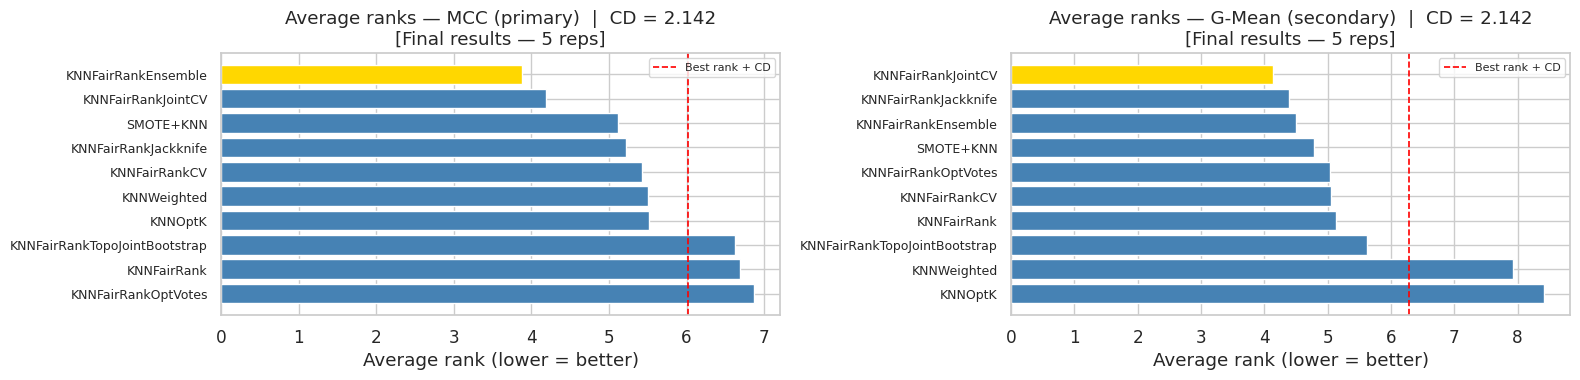

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, label in zip(axes, ["mcc", "geometric_mean"], ["MCC (primary)", "G-Mean (secondary)"]):
    ranks = average_ranks(bench_df, metric=metric)
    cd    = critical_difference(bench_df, metric=metric)

    print(f"\nAverage ranks ({label}) [{MODE_LABEL}]:")
    print(ranks.round(3).to_string())
    print(f"Critical difference (Nemenyi α=0.05): {cd:.3f}")

    colors_rank = ["gold" if ranks.iloc[i] == ranks.min() else "steelblue" for i in range(len(ranks))]
    ax.barh(range(len(ranks)), ranks.values, color=colors_rank, edgecolor="white")
    ax.set_yticks(range(len(ranks))); ax.set_yticklabels(ranks.index, fontsize=9)
    ax.set_xlabel("Average rank (lower = better)")
    ax.set_title(f"Average ranks — {label}  |  CD = {cd:.3f}\n[{MODE_LABEL}]")
    ax.axvline(ranks.min() + cd, color="red", linestyle="--", linewidth=1.2, label="Best rank + CD")
    ax.legend(fontsize=8); ax.invert_yaxis()

    ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / f"average_ranks_{metric}_{FILE_SUFFIX}.csv")

plt.tight_layout()
fig.savefig(FIG_DIR / f"average_ranks_{FILE_SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Degenerate Dataset Analysis  *(Exploratory)*

Datasets with fewer than `2 × cv_folds` minority samples were excluded from the
main Demšar analysis because 10-fold CV cannot guarantee even one minority example
per test fold (some folds yield NaN metrics). Here we re-analyse them with a
modified CV scheme (5-fold × 2× repetitions, same total evaluations) and report
**descriptive statistics only** — with ≈ 9 datasets there is no statistical power
for Wilcoxon or Friedman tests.

Key research question: does **SMOTE** hold a structural advantage when the minority
class is extremely small (7–19 samples), as the theoretical argument predicts?


In [22]:
# ── 7.1 Data preparation ────────────────────────────────────────────────────────
_degen_ok = (
    'degen_bench_df' in globals()
    and degen_bench_df is not None
    and len(degen_bench_df) > 0
)

if _degen_ok:
    degen_bench = _derive_metrics(degen_bench_df.copy())
    degen_agg   = (
        degen_bench
        .groupby(['dataset', 'algorithm'])[['mcc', 'geometric_mean', 'f1', 'roc_auc', 'pr_auc']]
        .mean().reset_index()
    )
    if RUN_MODE == 'full':
        degen_agg = degen_agg[degen_agg['algorithm'].isin(FINAL_ALGS)].copy()

    _n_degen_ds  = degen_agg['dataset'].nunique()
    _n_degen_alg = degen_agg['algorithm'].nunique()
    _cv_info = (
        f'{_DEGEN_FOLDS}-fold x {DEGEN_REPS} reps'
        if DEGEN_REPS else
        f"{degen_bench['repeat'].nunique()} reps (custom)"
    )

    degen_summary = (
        degen_agg.groupby('algorithm')[['mcc', 'geometric_mean', 'f1', 'roc_auc', 'pr_auc']]
        .mean().sort_values('geometric_mean', ascending=False)
    )
    degen_summary.columns = ['MCC', 'G-Mean', 'F1', 'ROC-AUC', 'PR-AUC']

    display(Markdown(
        f'**{_n_degen_ds} degenerate datasets** | CV: {_cv_info} | '
        f'{_n_degen_alg} algorithms'
    ))
    print('\nMean performance — descriptive only, no statistical testing:')
    print(degen_summary.round(4).to_string())
else:
    display(Markdown(
        '> **Degenerate analysis skipped** — no results available.  \n'
        '> Run the degenerate benchmark cell (Section 4) or set `CUSTOM_DEGEN_FILE`.'
    ))


**9 degenerate datasets** | CV: 5-fold x 10 reps | 10 algorithms


Mean performance — descriptive only, no statistical testing:
                                  MCC  G-Mean      F1  ROC-AUC  PR-AUC
algorithm                                                             
KNNFairRankJointCV             0.4085  0.7097  0.4403   0.7860  0.3630
KNNFairRankOptVotes            0.3529  0.7065  0.3790   0.7827  0.2974
KNNFairRank                    0.3946  0.6614  0.4266   0.8103  0.4130
KNNFairRankJackknife           0.4105  0.6504  0.4373   0.8202  0.4848
KNNFairRankCV                  0.3747  0.6115  0.4087   0.8041  0.4310
KNNWeighted                    0.3911  0.6064  0.4242   0.7784  0.4606
SMOTE+KNN                      0.3883  0.5591  0.4240   0.8101  0.4761
KNNFairRankTopoJointBootstrap  0.3282  0.5553  0.3774   0.7650  0.4018
KNNFairRankEnsemble            0.3334  0.5219  0.3534   0.8363  0.5726
KNNOptK                        0.3556  0.4376  0.3761   0.7254  0.4113


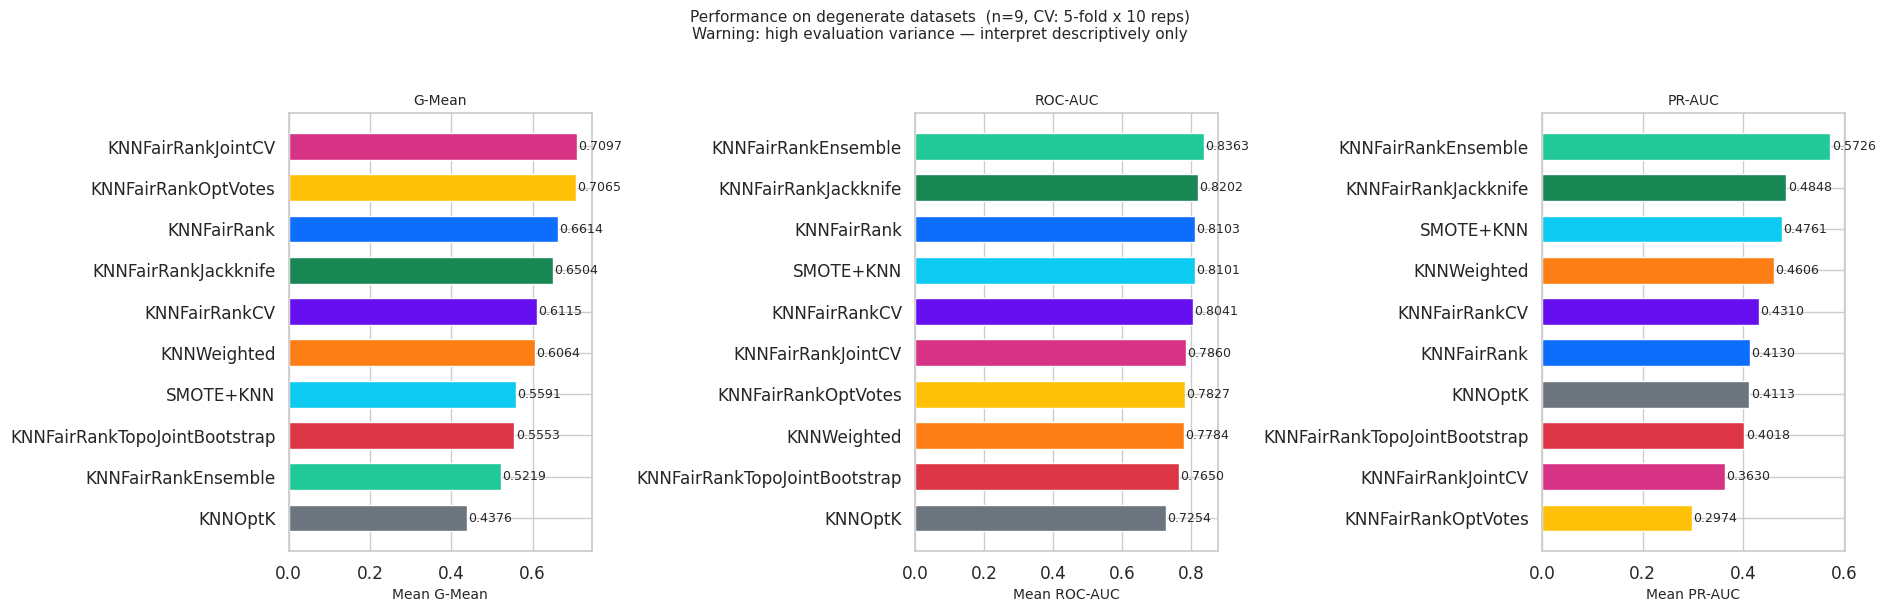

In [23]:
# ── 7.2 Performance bar charts ──────────────────────────────────────────────────
if _degen_ok:
    _D_PAL = {
        'KNNOptK': '#6c757d', 'KNNWeighted': '#fd7e14', 'SMOTE+KNN': '#0dcaf0',
        'KNNFairRank': '#0d6efd', 'KNNFairRankCV': '#6610f2',
        'KNNFairRankEnsemble': '#20c997', 'KNNFairRankOptVotes': '#ffc107',
        'KNNFairRankJointCV': '#d63384', 'KNNFairRankJackknife': '#198754',
        'KNNFairRankTopoJointBootstrap': '#dc3545',
    }
    fig, axes = plt.subplots(1, 3, figsize=(19, max(4, _n_degen_alg * 0.6)))
    for ax, metric, xlabel in [
        (axes[0], 'geometric_mean',  'Mean G-Mean'),
        (axes[1], 'roc_auc', 'Mean ROC-AUC'),
        (axes[2], 'pr_auc',  'Mean PR-AUC'),
    ]:
        means  = degen_agg.groupby('algorithm')[metric].mean().sort_values()
        colors = [_D_PAL.get(a, '#adb5bd') for a in means.index]
        bars   = ax.barh(means.index, means.values, color=colors,
                         edgecolor='white', height=0.65)
        for bar, val in zip(bars, means.values):
            ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
    axes[0].set_title('G-Mean', fontsize=10)
    axes[1].set_title('ROC-AUC', fontsize=10)
    axes[2].set_title('PR-AUC', fontsize=10)
    plt.suptitle(
        f'Performance on degenerate datasets  (n={_n_degen_ds}, CV: {_cv_info})\n'
        'Warning: high evaluation variance — interpret descriptively only',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'degen_performance.png', bbox_inches='tight')
    plt.show()


In [24]:
# ── 7.3 Average ranks and key finding ──────────────────────────────────────────
if _degen_ok:
    _dp = {
        m: degen_agg.pivot(index='dataset', columns='algorithm', values=m).dropna()
        for m in ['geometric_mean', 'roc_auc', 'pr_auc']
    }
    degen_ranks = pd.DataFrame({
        'G-Mean':  _dp['geometric_mean'].rank(axis=1, ascending=False).mean(),
        'ROC-AUC': _dp['roc_auc'].rank(axis=1, ascending=False).mean(),
        'PR-AUC':  _dp['pr_auc'].rank(axis=1, ascending=False).mean(),
    }).sort_values('G-Mean')

    print(f'Average ranks on {_n_degen_ds} degenerate datasets  (1 = best):')
    print(degen_ranks.round(2).to_string())

    _best_g = degen_ranks['G-Mean'].idxmin()
    _best_r = degen_ranks['ROC-AUC'].idxmin()
    _best_p = degen_ranks['PR-AUC'].idxmin()
    _smote  = degen_ranks.loc['SMOTE+KNN'] if 'SMOTE+KNN' in degen_ranks.index else None

    _msg = (
        f'**Key finding (n={_n_degen_ds}, descriptive):**  \n'
        f'- Best G-Mean: **{_best_g}**  \n'
        f'- Best ROC-AUC: **{_best_r}**  \n'
        f'- Best PR-AUC: **{_best_p}**  \n'
    )
    if _smote is not None:
        _msg += (
            f'- SMOTE+KNN ranks — G-Mean: **#{_smote["G-Mean"]:.1f}**, '
            f'ROC-AUC: **#{_smote["ROC-AUC"]:.1f}**, '
            f'PR-AUC: **#{_smote["PR-AUC"]:.1f}** (of {_n_degen_alg})  \n'
        )
    _msg += (
        '\n*With n ≈ 9 datasets rank differences are not statistically testable. '
        'Results are consistent with the theoretical expectation that SMOTE holds '
        'a structural advantage when minority class is extremely small — it adds '
        'training information while rank-correction methods operate on the same '
        'sparse minority sample.*'
    )
    display(Markdown(_msg))


Average ranks on 9 degenerate datasets  (1 = best):
                               G-Mean  ROC-AUC  PR-AUC
algorithm                                             
KNNFairRankOptVotes              3.22     6.50    9.17
KNNFairRank                      3.33     4.17    5.72
KNNFairRankJointCV               3.33     7.06    7.94
KNNFairRankJackknife             4.56     3.67    3.11
KNNFairRankTopoJointBootstrap    6.11     6.56    7.11
SMOTE+KNN                        6.17     4.67    4.22
KNNWeighted                      6.44     6.22    4.56
KNNFairRankCV                    6.56     4.83    4.94
KNNFairRankEnsemble              7.11     1.89    1.33
KNNOptK                          8.17     9.44    6.89


**Key finding (n=9, descriptive):**  
- Best G-Mean: **KNNFairRankOptVotes**  
- Best ROC-AUC: **KNNFairRankEnsemble**  
- Best PR-AUC: **KNNFairRankEnsemble**  
- SMOTE+KNN ranks — G-Mean: **#6.2**, ROC-AUC: **#4.7**, PR-AUC: **#4.2** (of 10)  

*With n ≈ 9 datasets rank differences are not statistically testable. Results are consistent with the theoretical expectation that SMOTE holds a structural advantage when minority class is extremely small — it adds training information while rank-correction methods operate on the same sparse minority sample.*

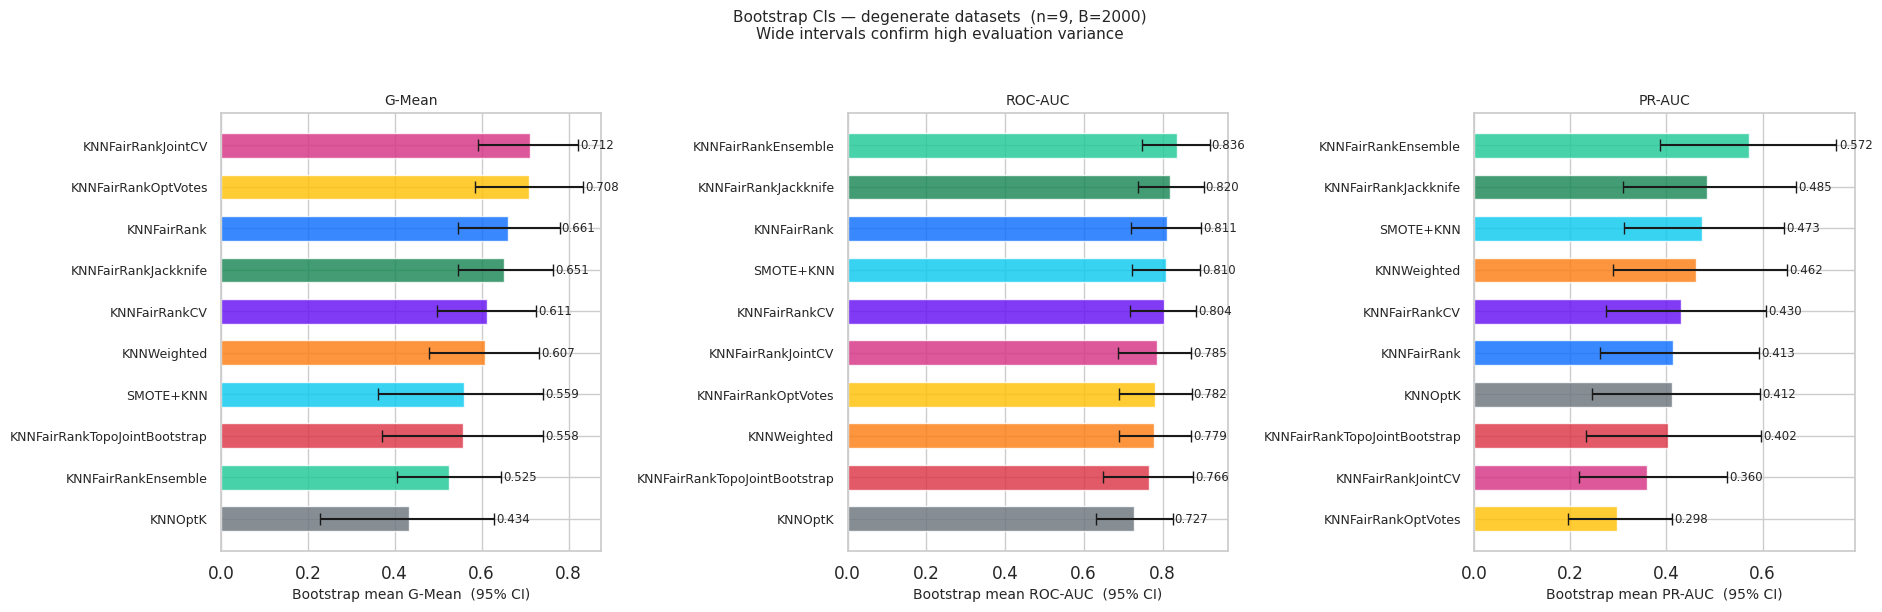

In [25]:
# ── 7.4 Bootstrap confidence intervals (full/custom-final mode only) ────────────
if _degen_ok and IS_FINAL:
    _rng_d = np.random.default_rng(SEED)
    _B_d   = 2000
    _ds_d  = degen_agg['dataset'].unique()
    _boot_d = {}
    for alg in degen_agg['algorithm'].unique():
        _sub = degen_agg[degen_agg['algorithm'] == alg].set_index('dataset')
        for m in ['geometric_mean', 'roc_auc', 'pr_auc']:
            vals = _sub.reindex(_ds_d)[m].dropna().values
            if len(vals) == 0:
                continue
            idx = _rng_d.integers(0, len(vals), (_B_d, len(vals)))
            _boot_d.setdefault(alg, {})[m] = vals[idx].mean(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(19, max(4, len(_boot_d) * 0.6)))
    for ax, metric, xlabel in [
        (axes[0], 'geometric_mean',  'G-Mean'),
        (axes[1], 'roc_auc', 'ROC-AUC'),
        (axes[2], 'pr_auc',  'PR-AUC'),
    ]:
        _order = sorted(
            (a for a in _boot_d if metric in _boot_d[a]),
            key=lambda a: _boot_d[a][metric].mean()
        )
        for i, alg in enumerate(_order):
            b      = _boot_d[alg][metric]
            lo, hi = np.percentile(b, [2.5, 97.5])
            c      = _D_PAL.get(alg, '#adb5bd')
            ax.barh(i, b.mean(), color=c, alpha=0.82, edgecolor='white', height=0.6,
                    xerr=[[b.mean() - lo], [hi - b.mean()]], capsize=4)
            ax.text(hi + 0.005, i, f'{b.mean():.3f}', va='center', fontsize=8.5)
        ax.set_yticks(range(len(_order)))
        ax.set_yticklabels(_order, fontsize=9)
        ax.set_xlabel(f'Bootstrap mean {xlabel}  (95% CI)', fontsize=10)
        ax.set_title(xlabel, fontsize=10)

    plt.suptitle(
        f'Bootstrap CIs — degenerate datasets  (n={_n_degen_ds}, B={_B_d})\n'
        'Wide intervals confirm high evaluation variance',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'degen_bootstrap_ci.png', bbox_inches='tight')
    plt.show()
elif _degen_ok and not IS_FINAL:
    display(Markdown(
        '> Bootstrap CIs for degenerate datasets shown in **full mode** only.'
    ))
